In [ ]:
"""
TO DO
> verify if better to save functions outside this script as .py to run it with .bat and Windows Scheduler
"""

In [ ]:
import sys

print("Python version:", sys.version)

import scipy
print(scipy.__version__)

In [ ]:
import sys
print(sys.path)

In [ ]:
import scipy
print(scipy.__file__)

In [3]:
import pandas as pd
import configparser
import pylab as pl
import os
from datetime import datetime, timedelta
import shutil
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import convolve

In [4]:
# FUNCTION TO WRITE THE DIRECTORY PATH OF DATA
# Depending on the reactor number (1 or 2) as contained in directory name
def get_directory_path(base_directory, reactor):    
    # Create a subdirectory name based on the 'reactor' string
    subdirectory_name = reactor
    
    # Combine the base directory and subdirectory to get the full path
    full_directory_path = os.path.join(base_directory, subdirectory_name)
    # Replace backslashes with forward slashes
    full_directory_path = full_directory_path.replace('\\', '/')
    
    return full_directory_path
# -----------------------------------------------------------------------------------------------------------------
# WRITE DIRECTORY PATH FOR REACTOR 1 OR 2
base_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/'
reactor_number = 2
reactor = f'R{reactor_number}'
print(get_directory_path(base_directory,reactor))

C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/R2


In [5]:
# FUNCTION TO FIND #'num_files' MOST RECENT DATA FILES IN THE DIRECTORY 
# Depending on the distance of the timestamp written in the file name with respect to the current date of running
def load_most_recent_csv_files(directory_path,num_files=2):
    # Step 1: List all .ini files in the directory
    csv_files = [file for file in os.listdir(directory_path) if file.endswith(".csv")]

    if not csv_files:
        no_files = 'No .csv files in the directory'
        return _, no_files, _

    # Step 2: Extract timestamps from the file names
    timestamps = [datetime.strptime(file.split('_')[0], "%Y-%m-%d") for file in csv_files]

    # Step 3: Sort timestamps in descending order (most recent first)
    current_timestamp = datetime.now()
    closest_timestamp = min(timestamps, key=lambda x: abs(x - current_timestamp))
    sorted_timestamps = sorted(timestamps, reverse=True)

    # Step 4: Get the most recent N timestamps
    recent_timestamps = sorted_timestamps[:num_files]

    # Step 5: Load the corresponding CSV files
    csv_file_paths = [os.path.join(directory_path, f"{timestamp.strftime('%Y-%m-%d')}_R2.csv") for timestamp in recent_timestamps]

    # Check if the closest timestamp is within one day. If not, return warning
    warning_msg = "No .csv file within one day of the current timestamp. Loading the nearest .csv file." if abs(current_timestamp - closest_timestamp) > timedelta(days=1) else 'Ok loading .csv'
    
    # Load and return the .ini file
    success_msg = f"Loading .csv file: {csv_file_paths}"
    print('\n'.join(csv_file_paths))
    return csv_file_paths, success_msg, warning_msg
# -----------------------------------------------------------------------------------------------------------------
# FIND THE TWO MOST RECENT DAYS OF DATA
num_recent_files = 2
directory_path = get_directory_path(base_directory,reactor)
recent_csv_files, success_find_data, warning_find_data = load_most_recent_csv_files(directory_path, num_recent_files)

C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/R2\2024-02-05_R2.csv
C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/R2\2024-02-04_R2.csv


In [6]:
# FUNCTION TO LOAD THE CSV DATA FILES
# It returns a dataframe (empty if it fails)
def read(recent_csv_files):
    file_path = recent_csv_files.replace('\\', '/')
    
    try:
        # Read the .csv file and append the dataframe to the list
        df = pd.read_csv(file_path,encoding='ISO-8859-1',delimiter = ';', 
                   parse_dates=['Timestamp'], dayfirst=True)
        success_reading = f"Successfully read {file_path}"
        print(success_reading)
        return df,success_reading
    
    except Exception:
        success_reading = f"Failed reading {file_path}"
        return [],success_reading
# -----------------------------------------------------------------------------------------------------------------
# LOAD DATA FOR CURRENT AND PREVIOUS DAYS
# Concatenate the two dataframes into one called 'combined_dataframe'
try:
    today,success_read_data = read(recent_csv_files[0])
    yesterday,success_read_data = read(recent_csv_files[1])
    combined_dataframe = pd.concat([yesterday,today], ignore_index=True)
    error_read_data = 'No'
    
except Exception as e:
    print(e)
    error_read_data = e

Successfully read C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/R2/2024-02-05_R2.csv
Successfully read C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Sperimentazione UIT/Software/R2/2024-02-04_R2.csv


In [7]:
# Calculate mean and standard deviation of dataset (not strictly necessary)
# To have an idea of the threshold to be used for outlier detection and replacement
mean_R2 = combined_dataframe['2F1.1 [L/h]'].mean()
stdev_R2 = combined_dataframe['2F1.1 [L/h]'].std()
print(f"""dataset_gas_rate_mean = {mean_R2},
dataset_gas_rate_mean = {stdev_R2}""")

dataset_gas_rate_mean = 0.8133265513733469,
dataset_gas_rate_mean = 1.5869298931195244


In [8]:
# CODE FOR OUTLIER DETECTION AND REPLACEMENT
# It finds the data points with Z-score > threshold
# Substitutes those data point with a linear interpolation between the previous and the next 'non-outlier' data points
# QUESTION: Z-score method: average and st.dev. calculated with respect to the overall time series 
#or with respect to the sliding window?
try:
    rate = f'{reactor_number}F1.1 [L/h]' # Gas rate
    ch4 = f'{reactor_number}X11Q3 [V% CH4]' # Methane percentage in gas
    co2 = f'{reactor_number}X11Q2 [V% CO2]' # Carbon dioxide percentage in gas
    # Compute Z-score
    combined_dataframe['Z-score_rate'] = np.abs((combined_dataframe[rate] - combined_dataframe[rate].mean()) / combined_dataframe[rate].std())
    combined_dataframe['Z-score_ch4'] = np.abs((combined_dataframe[ch4] - combined_dataframe[ch4].mean()) / combined_dataframe[ch4].std())
    combined_dataframe['Z-score_co2'] = np.abs((combined_dataframe[co2] - combined_dataframe[co2].mean()) / combined_dataframe[co2].std())
    
    threshold = 6  # Define your threshold for Z-score (higher than usual becouse of discontinuous mixing)
    
    # Find indices of outliers
    outlier_indices_rate = np.where(combined_dataframe['Z-score_rate'] > threshold)[0]
    outlier_indices_ch4 = np.where(combined_dataframe['Z-score_ch4'] > threshold)[0]
    outlier_indices_co2 = np.where(combined_dataframe['Z-score_co2'] > threshold)[0]
    #combined_dataframe['2F1.1 [L/h]_out'] = np.where(combined_dataframe['Z-score'] > threshold, combined_dataframe['2F1.1 [L/h]'].rolling(window=50, min_periods=1, center=True).mean(), combined_dataframe['2F1.1 [L/h]'])

    # Create a new column 'interpolated_data' with the original data
    combined_dataframe[f'{reactor_number}F1.1 [L/h]_out'] = combined_dataframe[rate]
    combined_dataframe[f'{reactor_number}X11Q3 [V% CH4]_out'] = combined_dataframe[ch4]
    combined_dataframe[f'{reactor_number}X11Q2 [V% CO2]_out'] = combined_dataframe[co2]

    # Replace outliers with linear interpolation
    interpolated_values_list_rate = []
    interpolated_values_list_ch4 = []
    interpolated_values_list_co2 = []

    for idx in outlier_indices_rate:
        prev_idx = idx-1
        while prev_idx in outlier_indices_rate:
            prev_idx = prev_idx-1
        next_idx = idx+1
        while next_idx in outlier_indices_rate:
            next_idx = next_idx+1
        interpolated_value = combined_dataframe.at[prev_idx, f'{reactor_number}F1.1 [L/h]_out'] + ((idx - prev_idx) * (combined_dataframe.at[next_idx, f'{reactor_number}F1.1 [L/h]_out'] - combined_dataframe.at[prev_idx, f'{reactor_number}F1.1 [L/h]_out'])) / (next_idx - prev_idx)
        interpolated_values_list_rate.append(prev_idx)
        combined_dataframe.at[idx, f'{reactor_number}F1.1 [L/h]_out'] = interpolated_value

    for idx in outlier_indices_ch4:
        prev_idx = idx-1
        while prev_idx in outlier_indices_ch4:
            prev_idx = prev_idx-1
        next_idx = idx+1
        while next_idx in outlier_indices_ch4:
            next_idx = next_idx+1
        interpolated_value = combined_dataframe.at[prev_idx, f'{reactor_number}X11Q3 [V% CH4]_out'] + ((idx - prev_idx) * (combined_dataframe.at[next_idx, f'{reactor_number}X11Q3 [V% CH4]_out'] - combined_dataframe.at[prev_idx, f'{reactor_number}X11Q3 [V% CH4]_out'])) / (next_idx - prev_idx)
        interpolated_values_list_ch4.append(prev_idx)
        combined_dataframe.at[idx, f'{reactor_number}X11Q3 [V% CH4]_out'] = interpolated_value

    for idx in outlier_indices_co2:
        prev_idx = idx-1
        while prev_idx in outlier_indices_co2:
            prev_idx = prev_idx-1
        next_idx = idx+1
        while next_idx in outlier_indices_co2:
            next_idx = next_idx+1
        interpolated_value = combined_dataframe.at[prev_idx, f'{reactor_number}X11Q2 [V% CO2]_out'] + ((idx - prev_idx) * (combined_dataframe.at[next_idx, f'{reactor_number}X11Q2 [V% CO2]_out'] - combined_dataframe.at[prev_idx, f'{reactor_number}X11Q2 [V% CO2]_out'])) / (next_idx - prev_idx)
        interpolated_values_list_co2.append(prev_idx)
        combined_dataframe.at[idx, f'{reactor_number}X11Q2 [V% CO2]_out'] = interpolated_value

    # Updated time series data with outliers replaced by interpolated values
    updated_time_series_rate = combined_dataframe[f'{reactor_number}F1.1 [L/h]_out']
    updated_time_series_ch4 = combined_dataframe[f'{reactor_number}X11Q3 [V% CH4]_out']
    updated_time_series_co2 = combined_dataframe[f'{reactor_number}X11Q2 [V% CO2]_out']
    error_outlier = 'No'
    
except Exception as e:
    error_outlier = e
    # Print an error message if there's an issue with the outlier detection
    print(e)
    # Return columns that are recalled later in the script equal to the original signal
    combined_dataframe[f'{reactor_number}F1.1 [L/h]_out'] = combined_dataframe[rate]
    combined_dataframe[f'{reactor_number}X11Q3 [V% CH4]_out'] = combined_dataframe[ch4]
    combined_dataframe[f'{reactor_number}X11Q2 [V% CO2]_out'] = combined_dataframe[co2]

In [9]:
# Calculate methane flowrate ('ch4_rate') and gas ratio ('ratio') as ch4/co2
# If there are values with co2% = 0, return 0 for that time instant 
try:
    rate = f'{reactor_number}F1.1 [L/h]' # Gas rate
    ch4 = f'{reactor_number}X11Q3 [V% CH4]' # Methane percentage in gas
    co2 = f'{reactor_number}X11Q2 [V% CO2]' # Carbon dioxide percentage in gas
    combined_dataframe['ch4_rate'] = combined_dataframe[rate]*combined_dataframe[ch4]/100
    # Identify rows where 'co2' column is 0
    zero_value_rows = combined_dataframe[combined_dataframe[co2] == 0]
    # Print the corresponding 'timestamp' values
    null_values_msg = 'Yes' if combined_dataframe[co2].any() == 0 else 'No'
    print("Timestamps corresponding to rows with 'co2' = 0:")
    print(zero_value_rows['Timestamp'].tolist())
    combined_dataframe['gas_ratio'] = np.where(combined_dataframe[co2] == 0, 0, combined_dataframe[ch4]/combined_dataframe[co2])
    error_calc = 'No'
    
except Exception as e:
    error_calc = e
    print(e)

Timestamps corresponding to rows with 'co2' = 0:
[]


In [10]:
# FUNCTION FOR FIR FILTERING OF DATA (moving average)
def moving_average_filter(signal, window_size):
    try:
        kernel = np.ones(window_size) / window_size
        filtered_signal = convolve(signal, kernel, mode='valid')
        return np.concatenate((np.full(window_size - 1, np.nan), filtered_signal), axis=0), 'No'
    except Exception as e:
        filtering_msg = f'{e} happend while filtering. Returning unfiltered signal'
        return signal, filtering_msg
# ----------------------------------------------------------------------------------------------------------------------
# FILTER DATA TO BUFFER THE DISCONTINUOUS MIXING 'impulsive' BEHAVIOUR OF DATA
# QUESTION: better to avoid filtering 'ratio' since it is a discontinuous measurment (1 every 3 liters of gas)?
window_size = 60 #minutes (QUESTION: must contains at least two consequent mixing cycles?)

# Apply the moving average filter to the dataset columns
combined_dataframe['filtered_gasrateoriginal'],filter_error = moving_average_filter(combined_dataframe[f'{reactor_number}F1.1 [L/h]'], window_size)
combined_dataframe['filtered_gas_rate'], filter_error = moving_average_filter(combined_dataframe[f'{reactor_number}F1.1 [L/h]_out'], window_size)
combined_dataframe['filtered_ch4_rate'],filter_error = moving_average_filter(combined_dataframe['ch4_rate'], window_size)
combined_dataframe['filtered_ratio'],filter_error = moving_average_filter(combined_dataframe['gas_ratio'], window_size)

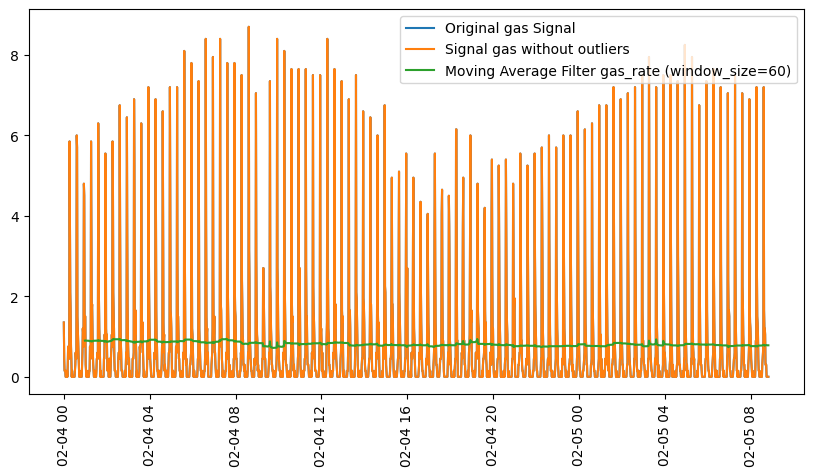

In [11]:
# Plotting the results: GAS RATE
try:
    fig,ax = plt.subplots(figsize=(10, 5))
    plt.plot(combined_dataframe['Timestamp'],combined_dataframe[f'{reactor_number}F1.1 [L/h]'], label='Original gas Signal')
    plt.plot(combined_dataframe['Timestamp'],combined_dataframe[f'{reactor_number}F1.1 [L/h]_out'], label=f'Signal gas without outliers')
    plt.plot(combined_dataframe['Timestamp'],combined_dataframe['filtered_gas_rate'], label=f'Moving Average Filter gas_rate (window_size={window_size})')
    ax = plt.gca()
    plt.xticks(rotation=90)
    plt.legend()
    plt.show()
    plot_file_name = f"gas_rate_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
    save_directory = "C:\\Users\\lenovo\\OneDrive - Politecnico di Milano\\Work_cloud\DOTTORATO\\Modelling\\Pilot_plant\\UIT controller\\Figures"
    fig.savefig(f"{save_directory}\\{plot_file_name}")
    plt.close(fig)  # Close the plot to free up resources
except Exception as e:
    print(e)

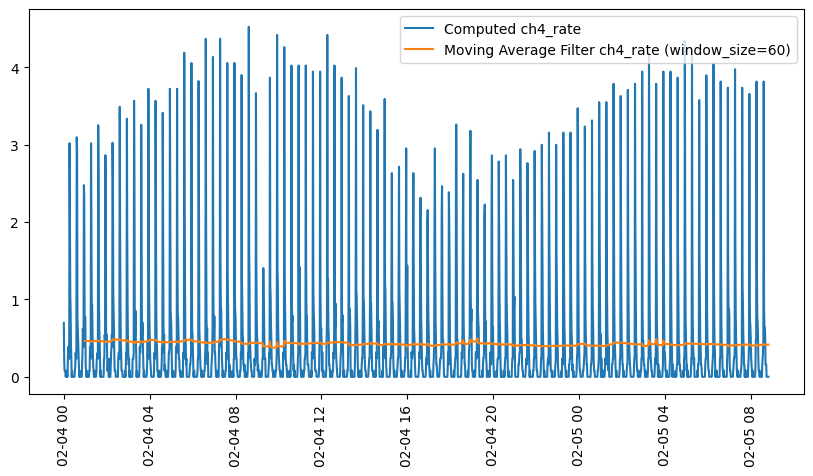

In [12]:
# Plotting the results: CH4 RATE
try:
    fig,ax = plt.subplots(figsize=(10, 5))
    plt.plot(combined_dataframe['Timestamp'],combined_dataframe['ch4_rate'], label=f'Computed ch4_rate')
    plt.plot(combined_dataframe['Timestamp'],combined_dataframe['filtered_ch4_rate'], label=f'Moving Average Filter ch4_rate (window_size={window_size})')
    plt.xticks(rotation=90)
    plt.legend()
    plt.show()
    plot_file_name = f"ch4_rate_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
    fig.savefig(plot_file_name)
    plt.close(fig)  # Close the plot to free up resources
except Exception as e:
    print(e)

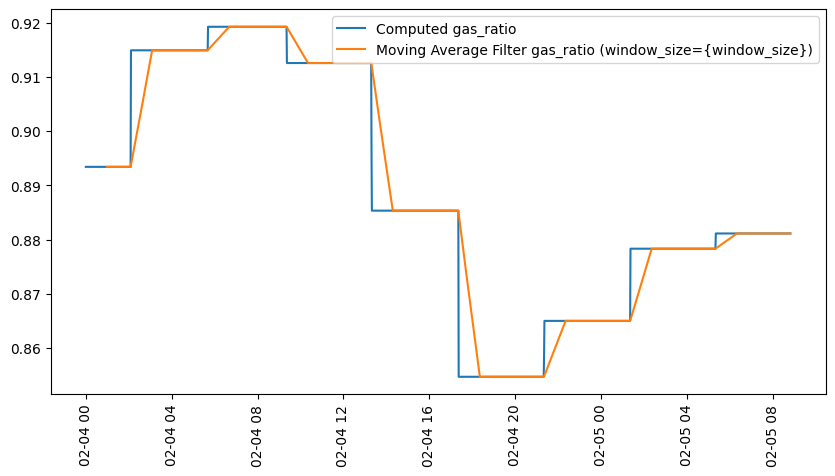

In [13]:
# Plotting the results: RATIO (note: co2/ch4!!)
try:
    fig,ax = plt.subplots(figsize=(10, 5))
    plt.plot(combined_dataframe['Timestamp'],1/combined_dataframe['gas_ratio'], label=f'Computed gas_ratio')
    plt.plot(combined_dataframe['Timestamp'],1/combined_dataframe['filtered_ratio'], label='Moving Average Filter gas_ratio (window_size={window_size})')
    ax = plt.gca()
    plt.xticks(rotation=90)
    plt.legend()
    plt.show()
    plot_file_name = f"gas_ratio_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
    fig.savefig(plot_file_name)
    plt.close(fig)  # Close the plot to free up resources
except Exception as e:
    print(e)

In [14]:
# FUNCTION TO DEFINE PI controller with saturation and anti wind-up
# Choice to saturate the integral term or not
# Logs quantities of interest in a dataframe 'log_df'
class PIController:
    # INIT
    def __init__(self, name, kp, ki, saturation_low=None, saturation_high=None, saturate_integral=True):
        self.name = name
        self.kp = kp
        self.ki = ki
        self.saturation_low = saturation_low
        self.saturation_high = saturation_high
        self.saturate_integral = saturate_integral
        self.log_df = pd.DataFrame(columns=['timestamp', 'error', 'integral','integral_past','u_p','u_i','u_i_past','control_signal','saturation','selection'])

    # -------------------------------------------------------------------------------------------------------------------
    # COMPUTE CONTROL SIGNAL FROM ERROR AND PAST INTEGRAL TERM
    def compute(self, error, dt, selection):
        # Past integral term loaded from the last row of dataframe 'log_df'
        integral_past = self.log_df['integral'].iloc[-1] if not self.log_df.empty else 0 #Default starting value
        # Integral 
        integral = integral_past + error * dt #dt = control interval

        # Apply saturation to the integral term if specified
        if self.saturate_integral:
            if self.saturation_low is not None and integral < self.saturation_low:
                integral = self.saturation_low
            elif self.saturation_high is not None and integral > self.saturation_high:
                integral = self.saturation_high

        # Calculate the control action
        u_p = self.kp * error # Proportional action
        u_i_past = self.ki*integral_past #Just for checking purposes. Must always be 'control_signal - u_p' at the previous iteration
        u_i = self.ki * integral # Integral action
        control_signal = u_p + u_i

        # Apply saturation to the control signal
        if self.saturation_low is not None and control_signal < self.saturation_low:
            control_signal = self.saturation_low
        elif self.saturation_high is not None and control_signal > self.saturation_high:
            control_signal = self.saturation_high
            
        # If 'control_signal' is in saturation, apply anti-windup
        if control_signal <= self.saturation_low:
            saturation = 'Low'
            integral = (control_signal - u_p)/self.ki
        elif control_signal >= self.saturation_high:
            saturation = 'High'
            integral = (control_signal - u_p)/self.ki
        else:
            saturation = 'No'

        # Log the quantities of interest
        timestamp = datetime.now()
        self.log_df = self.log_df.append({'timestamp': timestamp, 'error': error, 'integral': integral,'integral_past': integral_past,'u_p':u_p,'u_i':u_i,'u_i_past':u_i_past,
                                          'control_signal':control_signal,'saturation':saturation,'selection': selection}, ignore_index=True)
        
        return control_signal
    
    # -------------------------------------------------------------------------------------------------------------------
    # FUNCTION TO LOAD 'integral_past' FROM PREVIOUS CONTROL EVALUATIONS
    # Checks current date log. If not, takes the log file of the previous date
    # If there are no current and previous date log files, 'integral_past' restart from default value (0).
    def load_state(self, filename=None):
        # If filename is not provided, use a default filename based on the controller's name
        if filename is None:
            filename = f"{self.name}_{log_date}_state.csv"
        
        # Load the log_df DataFrame from a file
        try:
            self.log_df = pd.read_csv(filename)
            load_msg = f"Loaded integral state from {filename}"
            print(load_msg)
            
        except FileNotFoundError:
            previous_date = (datetime.now() - timedelta(days=1)).strftime("%Y-%m-%d")
            file_path_previous = f"{self.name}_{previous_date}_state.csv"
            try:
                self.log_df = pd.read_csv(file_path_previous).iloc[[-1]]
                load_msg = f"Loaded integral state for {self.name} from {file_path_previous}"
                print(load_msg)
                
            except FileNotFoundError:
                load_msg = f"No integral state file found for {self.name} from the current or previous day. Initializing from default state."
                print(load_msg)
        return load_msg
                
    # -------------------------------------------------------------------------------------------------------------------
    # REINIT FUNCTION 
    # ADD a line to the log of the controller whose state must be reinitialized at the current control evaluation
    # With a desired value to allow for coherence between the states of the two controllers
    # To be run before control computation, so that 'desired_value' is laoded as the last row of 'integral'
    def reset_state(self, desired_value):
        timestamp = datetime.now()
        new_row = {'timestamp': timestamp, 'error': '-', 'integral': desired_value,'control_signal':'-','selection': str('reselected')}
        self.log_df = self.log_df.append(new_row, ignore_index=True)
        
    # -------------------------------------------------------------------------------------------------------------------
    # FUNCTION TO SAVE QUANTITIES OF INTEREST TO CSV AT THE CURRENT CONTROLLER EVALUATION
    # Usefull for the control evaluation at the next control instant 
    def save_state(self, filename=None):
        # If filename is not provided, use a default filename based on the controller's name
        if filename is None:
            filename = f"{self.name}_{log_date}_state.csv"
        
        # Save the log_df DataFrame to a file
        self.log_df.to_csv(filename, index=False)

In [15]:
# FUNCTION TO READ CSV FILES
# Used to read setpoint csv file
def read_csv_with_column_names(file_path):
    """
    Read a CSV file, check for its existence, and store it in a DataFrame.

    Parameters:
    - file_path (str): Path to the CSV file.

    Returns:
    - df (pd.DataFrame): DataFrame containing the data from the CSV file.
    """

    # Check if the file exists
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file '{file_path}' does not exist.")

    # Read the CSV file with the specified column names from the first row
    df = pd.read_csv(file_path, header=0)  # Set header=0 to use the first row as column names

    return df
# ---------------------------------------------------------------------------------------------------------------------------
# FUNCTION TO EXTRACT ROW CORRESPONDING TO CURRENT TIME OF CONTROL RUN
# From the 'setpoint' csv file, extract the nearest row to the current code runtime based on the rounded value of the 'Timestamp' column
# In the 'setpoint' csv file, 'Timestamp' column is rounded to one point for each hour (HH:00:00).
def extract_nearest_row(dataframe,current_time):
    """
    Extract the row from a DataFrame corresponding to the nearest current timestamp,
    rounded to the hour period.

    Parameters:
    - dataframe (pd.DataFrame): DataFrame with timestamp column.

    Returns:
    - nearest_row (pd.Series): Series containing the row data.
    """

    # Ensure that the DataFrame has a timestamp column
    if 'Timestamp' not in dataframe.columns:
        raise ValueError("DataFrame must have a 'timestamp' column.")

    # Get the current timestamp rounded to the hour period
    current_time = current_time.replace(microsecond=0, second=0, minute=0)

    # Find the index of the nearest timestamp in the DataFrame
    nearest_index = (dataframe['Timestamp'] - current_time).abs().idxmin()

    # Extract the row corresponding to the nearest timestamp
    nearest_row = dataframe.loc[nearest_index]

    return nearest_row

In [16]:
# FUNCTION TO DEFINE HYSTERESIS COMPARATOR
# To compare 'co2/ch4' measurement point with its safety threshold to trigger control switches
# 'co2/ch4' setpoint < treshold low > treshold high 
# Boolean state depending on 'co2/ch4' measurement laying below treshold low (False) or above treshold high (True)
# If 'co2/ch4' lays within the two tresholds, this function doesn't change its state
class HysteresisComparator:
    # INIT
    def __init__(self, threshold_low, threshold_high):
        self.threshold_low = threshold_low
        self.threshold_high = threshold_high
        #self.state = False  # Initial state
    # -------------------------------------------------------------------------------------------------------------------
        filename = f"Follower_{log_date}_state.csv"

        # Load the log_df DataFrame from a file
        try:
            log = pd.read_csv(filename)
            self.load_msg = f"Loaded hyst.comparator state from {filename}"
            print(self.load_msg)

        except FileNotFoundError:
            previous_date = (datetime.now() - timedelta(days=1)).strftime("%Y-%m-%d")
            file_path_previous = f"Follower_{previous_date}_state.csv"
            try:
                log = pd.read_csv(file_path_previous).iloc[[-1]]
                self.load_msg = f"Loaded hyst.comparator state for Follower from {file_path_previous}"
                print(self.load_msg)

            except FileNotFoundError:
                self.load_msg = f"No hyst.comparator state file found for Follower from the current or previous day. Initializing from default state."
                log = pd.DataFrame()
                print(self.load_msg)
                
        self.state =log['selection'].iloc[-1] if not log.empty else False #Default starting value
    # -------------------------------------------------------------------------------------------------------------------
    def loading_message(self):
        # Perform setup operation
        load_msg = self.load_msg

        # Return the result
        return load_msg
    # -------------------------------------------------------------------------------------------------------------------
    # UPDATE COMPARATOR STATE
    def update(self, value):
        if value < self.threshold_low:
            self.state = False
        elif value > self.threshold_high:
            self.state = True
        # If the value is between the thresholds, maintain the current state
        #What if threshold_high<threshold_low ?

        return self.state
    # -------------------------------------------------------------------------------------------------------------------
    # FUNCTION TO MOVE FROM STATE TO STRING (needed for later code usage)
    def get_state_as_string(self):
        return str(self.state)

In [21]:
# FUNCTION TO LOG QUANTITIES OF INTEREST OF THE CODE RUN TO A CSV FILE
# Reads and appends current run row to dataframe 
def append_row_to_csv(file_path, new_row_dict):
    """
    Append a new row (in the form of a dictionary) to a CSV file.

    Parameters:
    - file_path (str): Path to the CSV file.
    - new_row_dict (dict): Dictionary representing the new row.

    Returns:
    - None
    """

    # Check if the file exists
    if not pd.io.common.file_exists(file_path):
        # If the file doesn't exist, create a new DataFrame with the header
        df = pd.DataFrame(columns=new_row_dict.keys())
    else:
        # If the file exists, read the existing DataFrame from the CSV
        df = pd.read_csv(file_path)

    # Append the new row to the DataFrame
    timestamp = datetime.now()
    df = df.append({'Timestamp_control':timestamp,**new_row_dict}, ignore_index=True)

    # Write the DataFrame back to the CSV file
    df.to_csv(file_path, index=False)

In [22]:
# START OF CONTROL COMPUTATION FOR THE CURRENT CONTROL EVALUATION
# -------------------------------------------------------------------------------------------------------------------
# Define current date (for logging)
current_date = datetime.now().strftime('%Y-%m-%d')
log_date = current_date
# -------------------------------------------------------------------------------------------------------------------
# READ DATA POINT FOR THE CURRENT CODE RUN (LAST ROW OF THE READ CSV FILES)
# QUESTION: read 'co2/ch4' setpoint from file or fix constant value? 
try:
    last_row = combined_dataframe.iloc[-1]
    current_time = last_row['Timestamp']
    # Methane flowrate
    measure1 = last_row['filtered_ch4_rate']
    # -------------------------------------- CONSTANT VALUES OR NOT?
    #CO2/CH4 gas ratio
    measure2 = 1/last_row['gas_ratio'] if last_row['gas_ratio'] != 0 else 0.842 #Number of "optim_ss" simulation of 26.01.2024
    meas_error = 'No error in reading meas from dataframe'
    
except Exception  as e:
    print(e)
    meas_error = e
# -------------------------------------------------------------------------------------------------------------------
# READ SETPOINTS FROM CSV FILE FOR THE CURRENT CODE RUN (nearest row with respect to 'current_time')
setpoints_file_path = 'setpoint_31.01.2024.csv'
try:
    setpoints = read_csv_with_column_names(setpoints_file_path)
    setpoints['Timestamp'] = pd.to_datetime(setpoints['Timestamp'], format="%Y-%m-%d %H:%M:%S")
    print("Setpoints loaded")
    # Extract row nearer to the current running time or last timestamp of the data files
    setpoints_row = extract_nearest_row(setpoints, current_time)
    setpoint_error = 'No'
    
except Exception  as e:
    print(e)
    setpoint_error = e
    setpoint_row = {'Setpoint1':measure1,'Setpoint2':measure2,'TresholdLow':measure2+0.05,'TresholdHigh':measure2+0.1}
    
# Declare variables extracting reading quantities from the above-defined csv file of setpoints
setpoint1 = setpoints_row['Setpoint1']
setpoint2 = setpoints_row['Setpoint2'] # -------------------------------------------- CONSTANT VALUES OR NOT?
threshold_low = setpoints_row['TresholdLow'] # -------------------------------------------- CONSTANT VALUES OR NOT?
threshold_high = setpoints_row['TresholdHigh'] # -------------------------------------------- CONSTANT VALUES OR NOT?
if setpoint2 > threshold_low or threshold_low > threshold_high:
    print('Uncorrect relation between setpoint2 and tresholds')

# Log for "boundary" conditions of the controller computations for the current evaluation
data_filepath = f'Buondary_calc_conditions_{log_date}.csv'
new_row_data = {'Timestamp_setpoints':setpoints_row['Timestamp'],'Timestamp_measures':current_time,
                'ch4_setpoint':setpoint1, 'ch4_measure':measure1,
                'co2/ch4_setpoint':setpoint2, 'co2/ch4_measure':measure2,
                'threshold_low':threshold_low,'threshold_high':threshold_high,
               }
append_row_to_csv(data_filepath, new_row_data)

Setpoints loaded


In [19]:
# COMPUTE ERRORS for the current evaluation run
error1 = setpoint1 - measure1
error2 = setpoint2 - measure2
dt = 2.5*3600  # Control interval in seconds! QUESTION: Fix it or compute from timestamps in the logs?
# -------------------------------------------------------------------------------------------------------------------
# DEFINE CONTROLLER PARAMETERS
saturation_high = 400/1e6
saturation_low = -95/1e6
kp1 = 0.003
kp2 = 0.008
Ti1 = 64000
Ti2 = 64000
# -------------------------------------------------------------------------------------------------------------------
# INIT AND LOAD CONTROLLER PAST STATE
try:
    #Initialize the PI controller controllers for each run
    controller1 = PIController(name = "Header", kp = kp1, ki = kp1/Ti1, saturation_low =saturation_low, saturation_high = saturation_high, saturate_integral=False)
    controller2 = PIController(name = "Follower", kp = kp2, ki = kp2/Ti2, saturation_low = saturation_low, saturation_high = saturation_high, saturate_integral=False)

    # Load the state from the previous run
    load_msg1 = controller1.load_state()
    load_msg2 = controller2.load_state()
    controller_error = 'No'
    
except Exception as e:
    print(e)
    load_msg1 = e
    load_msg2 = e
    controller_error = e

Loaded integral state for Header from Header_2024-02-05_state.csv
Loaded integral state for Follower from Follower_2024-02-05_state.csv


In [20]:
# SELECTION OF THE ACTIVE CONTROLLER (and eventual REINIT)
# Defines a boolean 'condition' as the state of the hysteresis comparator function
# When 'edge' of 'condition', REINIT is triggered
try:
    if not controller2.log_df.empty:
     controller2.log_df.loc[controller2.log_df.index[-1],'selection'] = controller2.log_df.at[controller2.log_df.index[-1],'selection'] == 'True'
    prev_condition = controller2.log_df.iloc[-1]['selection'] if not controller2.log_df.empty else False # Initialize the 'prev_condition'
    # Reset the state of controller1 using the last state of controller2 if the condition holds
    # It adds a row in the log.
    # QUESTION: Alternative: Dovrei cambiare struttura e, se condizione, non far leggere ultimo stato da file ma specificarlo direttamente
    derired_value_controller1 = (float(controller2.log_df.iloc[-1]['control_signal'])-controller1.kp*error1)/controller1.ki if not controller2.log_df.empty else 0
    derired_value_controller2 = (float(controller1.log_df.iloc[-1]['control_signal'])-controller2.kp*error2)/controller2.ki if not controller1.log_df.empty else 0

    #condition = True if measure2 > threshold else False
    hysteresis_comp = HysteresisComparator(threshold_low=threshold_low, threshold_high=threshold_high)
    load_msg_hyst = hysteresis_comp.loading_message()
    condition = hysteresis_comp.update(measure2)

    # Check for the edge condition change
    if condition != prev_condition and prev_condition == False:
     # Reinitialize the state of controllers based on the edge condition
     controller2.reset_state(derired_value_controller2)
    if condition != prev_condition and prev_condition == True:
     controller1.reset_state(derired_value_controller1)
    reinit_error = 'No'
    
except Exception as e:
    print(e)
    load_msg_hyst = e
    reinit_error = e

Loaded integral state for Follower from Follower_2024-02-05_state.csv


In [23]:
# COMPUTATION OF THE CONTROL ACTION FOR BOTH CONTROLLERS
# SWITCH SELECTION OF THE CONTROL ACTION BASED ON WHICH CONTROLLER IS ACTIVE (based on 'condition' defined above)
# Calculate the control output
try:
    control_output1 = controller1.compute(error1, dt, not condition)
    control_output2 = controller2.compute(error2, dt, condition)

    # Save the state of controllers for the next run
    controller1.save_state()
    controller2.save_state()

    #SWITCH
    # Choose between the two control signals based on the condition
    final_control_signal = control_output2 if condition else control_output1
    selector_error = 'No'
    
except Exception as e:
    selector_error = e
    print(e)

#print(controller1.log_df)
#print(controller2.log_df)

In [24]:
# CONVERT FLOAT (DISCRETE) CONTROL ACTION
# Move from tomato souce daily load (mL/day) to on/off interval duration of peristaltic pumps control
# QUESTION: center the control around the initial equilibrium and control action (10 ml/control interval) or around the optimal feeding strategy?
# If the second is persued, 'saturationLow' and 'on_minutes_nominal' must be varied in time 
try:
    pump_dose_per_minute = 10 #mL/min

    required_volume = final_control_signal*1e6/(24*60*60)*dt #mL
    
    max_on_minutes_delta = int(saturation_high*1e6/(24*60*60)*dt/pump_dose_per_minute) # Only for precaution/safety purposes as a double-check

    on_minutes_delta = max(-1, min(int(required_volume / pump_dose_per_minute), max_on_minutes_delta))

    on_minutes_nominal = 1

    on_minutes_tot = on_minutes_delta + on_minutes_nominal
    
    minutes_in_dt = dt/60 #Amount of minutes within the control time interval ('dt' in seconds)
    if on_minutes_tot > 0:
        dosing_interval = int(minutes_in_dt/on_minutes_tot) #Devide control interval in equal 'on_minutes_tot' fractions
        on_minutes_ini = 1 #Turn on the pump for one minute/control interval fraction
        off_minutes_ini = dosing_interval - 1
    else:
        dosing_interval = minutes_in_dt #If 'saturationLow', don't turn on pumps for any minute in the control interval
        on_minutes_ini = 0
        off_minutes_ini = dosing_interval

    #Compute values to be placed in .ini file (range 0...86400 seconds)
    on_seconds_ini = max(0, min(on_minutes_ini*60,86400))
    off_seconds_ini = max(0, min(off_minutes_ini*60,86400))
    conversion_error = 'No'
except Exception as e:
    conversion_error = e
    print(e)
# -------------------------------------------------------------------------------------------------------------------
# END OF CONTROL COMPUTATION FOR THE CURRENT CONTROL EVALUATION

#QUESTION: Alternative: Run the controller computation in case everything has been saved together as a python function
# What is better for running .bat with scheduler?
#success = selector()

# SUMMARY LOG TO CSV FILE for main outputs of the controller computation run
output_filepath = f'Output_selector_{log_date}.csv'
active_controller_name = controller2.name if condition else controller1.name
new_row_output = {'active':active_controller_name, 'ch4_error': error1, 'co2/ch4_error': error2, 
                  'c2/ch4-Trlow': measure2 - threshold_low, 'co2/ch4_TrHigh':measure2 - threshold_high, 
                  'final_control_signal':final_control_signal, 'on_minutes_tot':on_minutes_tot,
                  'on_seconds_ini':on_seconds_ini,'off_seconds_ini':off_seconds_ini
                 }
append_row_to_csv(output_filepath, new_row_output)

In [25]:
# FUNCTION TO FIND THE MOST RECENT AVAILABLE .INI FILE based on timestamp in its filename
# QUESTION: Input .ini (last available) must be taken from the last available file in "Parameter correct"...or from Bioreator/Parameter?
def load_closest_ini_file(directory_path):
    # Step 1: List all .ini files in the directory (PARAMETER_CORRECT)
    ini_files = [file for file in os.listdir(directory_path) if file.endswith(".ini")]

    if not ini_files:
        no_files = 'No .ini files in the directory'
        warning_msg = 'No .ini files in the directory'
        return None, no_files, warning_msg

    # Step 2: Extract timestamps from the file names
    timestamps = [datetime.strptime(file.split('_')[1] + '_' + file.split('_')[2].split('.')[0], "%Y-%m-%d_%H-%M-%S") for file in ini_files]

    # Step 3: Find the timestamp closest to the current timestamp
    current_timestamp = datetime.now()
    closest_timestamp = min(timestamps, key=lambda x: abs(x - current_timestamp))

    # Step 5: Load the corresponding .ini file
    closest_ini_file = f"Parameter_{closest_timestamp.strftime('%Y-%m-%d_%H-%M-%S')}.ini"
    ini_file_path = os.path.join(directory_path, closest_ini_file)
    
    # Check last modification...the time difference from now is higher than the control interval?
    file_modification_time = os.path.getmtime(ini_file_path)
    modification_datetime = datetime.fromtimestamp(file_modification_time)
    age = current_timestamp - modification_datetime
    
    # Check if the closest timestamp is within one day
    if abs(current_timestamp - closest_timestamp) > timedelta(days=1):
        warning_msg = "No .ini file within one day of the current timestamp. Loading the nearest .ini file."
        print(warning_msg)
    # Check if the closest timestamp is older than the control interval
    elif age.total_seconds() > dt+500:
        warning_msg = "No .ini file within 2.5 hours of the current timestamp. Loading the nearest .ini file."
        print(warning_msg)

    # Load and return the .ini file
    success_msg = f"Loading .ini file: {ini_file_path}"
    print(success_msg)
    return ini_file_path, success_msg, warning_msg
# --------------------------------------------------------------------------------------------------------------------------------
# FUNCTION TO READ THE MOST RECENT .INI FILE AND UPDATE IT
# New .ini file has to be placed in 'Remote' folder (output_directory)
def update_ini_file(input_config_file_path, input_directory, output_directory, on_seconds, off_seconds):
    # Read the original .ini file
    config = configparser.ConfigParser()
    config.read(input_config_file_path)

    # Modify the .ini file with control output
    on_seconds_actual = 60 if on_seconds > 60 else on_seconds 
    off_secons_actual = 9000 if off_seconds > 9000 else off_seconds
    
    config[f'REACTOR{reactor_number}']['feedpumpontime'] = str(on_seconds_actual)+',000000'
    config[f'REACTOR{reactor_number}']['feedpumpofftime'] = str(off_secons_actual)+',000000'
    #Alternative way to set parameters in .ini: config.set('REACTOR2', 'feedpumpontime', str(ciao))

    # Ensure the output directory exists
    #if not os.path.exists(output_directory):
    #    raise DirectoryNotFoundError(f"The directory {output_directory} does not exist.")

    # Save the modified .ini file in the specified output directory
    output_file_name = f"Parameter_{current_time.strftime('%Y-%m-%d_%H-%M-%S')}.ini"
    output_file_path = os.path.join(output_directory, output_file_name)
    output_file_path = output_file_path.replace('\\', '/')
    with open(output_file_path, 'w') as configfile:
        config.write(configfile)

    # Make a copy of the modified .ini file in another directory to keep track of them
    #copy_file_name = file_name.replace('.ini','_copy.ini')
    copy_file_path = os.path.join(input_directory, output_file_name)
    copy_file_path = copy_file_path.replace('\\', '/')
    shutil.copyfile(output_file_path, copy_file_path)
    success_msg = f"""Parameter_{current_time.strftime('%Y-%m-%d_%H-%M-%S')}.ini has been written in
    {output_file_path} and
    {copy_file_path}"""
    return success_msg

#How to check if it has been read by the programm? Controllo poi i log

In [ ]:
# FIND LAST AVAILABLE .INI AND UPDATE IT
# Find it in...
input_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Modelling/Pilot_plant/UIT controller'

# Update it and save to...
output_directory =  'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Modelling/Pilot_plant/UIT controller/Bioreactor'
# And a copy to... 
copy_directory = 'C:/Users/lenovo/OneDrive - Politecnico di Milano/Work_cloud/DOTTORATO/Modelling/Pilot_plant'

try:
    input_config_file_path, success_find_ini, warning_find_ini = load_closest_ini_file(input_directory)
    write_success_update = update_ini_file(input_config_file_path, copy_directory, output_directory, on_seconds_ini, off_seconds_ini)

except Exception as e:
    write_success_update = 'No update of .ini files becouse error in updating'
print(write_success_update)

In [ ]:
# SUMMARY LOG OF WARNING, ERRORS AND SUCCESS MESSAGES for the current control run
# Creates a txt in append mode for the current date
# Logs the messages along with the current timestamp to a text file
log_file_name = f"log_{datetime.now().strftime('%Y-%m-%d')}.txt"
log_message = f""" \n --------------------------------------------------------------------------------------------------------------------------------------- \n
{datetime.now()} \n
1 - {warning_find_data}. \n
1 - {success_find_data}. \n
2 - {success_read_data}. If failed, returning empty dataframe. \n
2 - {error_read_data}. \n
3 - {error_outlier}. If 'Yes', returning original data. \n
4 - {error_calc}. \n
5 - {filter_error}. \n
6 - {meas_error}. \n
7 - {setpoint_error}. \n
8 - {load_msg1}. \n
8 - {load_msg2}. \n
8 - {controller_error}. \n
9 - {load_msg_hyst}. \n
9 - {reinit_error}. \n
10 - {selector_error}. \n
11 - {conversion_error}. \n
12 - {success_find_ini}. \n
12 - {warning_find_ini}. \n
13 - {write_success_update}."""
with open(log_file_name, 'a') as log_file:
    log_file.write(log_message)